# DARS+ Model Applied to LeetCode Dataset

This notebook runs the DARS+ model on the LeetCode dataset, predicting problem difficulty/acceptance rates and evaluating model performance with comprehensive metrics and visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import math
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(2026)

# Configure plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load and Preprocess LeetCode Dataset

In [2]:
# Load the LeetCode dataset
csv_path = r'C:\Users\sunil\Downloads\btech-project\leetcode_dataset - lc.csv'
df = pd.read_csv(csv_path)

print(f"Original dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
display(df.head())
print(f"\nData types:\n{df.dtypes}")

Original dataset shape: (1825, 19)

Columns: ['id', 'title', 'description', 'is_premium', 'difficulty', 'solution_link', 'acceptance_rate', 'frequency', 'url', 'discuss_count', 'accepted', 'submissions', 'companies', 'related_topics', 'likes', 'dislikes', 'rating', 'asked_by_faang', 'similar_questions']

First few rows:


,id,title,description,is_premium,difficulty,solution_link,acceptance_rate,frequency,url,discuss_count,accepted,submissions,companies,related_topics,likes,dislikes,rating,asked_by_faang,similar_questions
0,1,Two Sum,Given an array of integers `nums` and an integ...,0,Easy,/articles/two-sum,46.7,100.0,https://leetcode.com/problems/two-sum,999,4.1M,8.7M,"Amazon,Google,Apple,Adobe,Microsoft,Bloomberg,...","Array,Hash Table",20217,712,97,1,"[3Sum, /problems/3sum/, Medium], [4Sum, /probl..."
1,2,Add Two Numbers,You are given two non-empty linked lists repre...,0,Medium,/articles/add-two-numbers,35.7,93.1,https://leetcode.com/problems/add-two-numbers,999,1.9M,5.2M,"Bloomberg,Microsoft,Amazon,Google,Facebook,App...","Linked List,Math,Recursion",11350,2704,81,1,"[Multiply Strings, /problems/multiply-strings/..."
2,3,Longest Substring Without Repeating Characters,"Given a string `s`, find the length of the lon...",0,Medium,/articles/longest-substring-without-repeating-...,31.5,90.9,https://leetcode.com/problems/longest-substrin...,999,2.1M,6.7M,"Amazon,Bloomberg,Microsoft,Facebook,Apple,Adob...","Hash Table,Two Pointers,String,Sliding Window",13810,714,95,1,[Longest Substring with At Most Two Distinct C...
3,4,Median of Two Sorted Arrays,Given two sorted arrays `nums1` and `nums2` of...,0,Hard,/articles/median-of-two-sorted-arrays,31.4,86.2,https://leetcode.com/problems/median-of-two-so...,999,904.7K,2.9M,"Amazon,Goldman Sachs,Facebook,Microsoft,Apple,...","Array,Binary Search,Divide and Conquer",9665,1486,87,1,NaN
4,5,Longest Palindromic Substring,"Given a string `s`, return the longest palindr...",0,Medium,/articles/longest-palindromic-substring,30.6,84.7,https://leetcode.com/problems/longest-palindro...,999,1.3M,4.1M,"Amazon,Microsoft,Wayfair,Facebook,Adobe,eBay,G...","String,Dynamic Programming",10271,670,94,1,"[Shortest Palindrome, /problems/shortest-palin..."



Data types:
id                     int64
title                 object
description           object
is_premium             int64
difficulty            object
solution_link         object
acceptance_rate      float64
frequency            float64
url                   object
discuss_count          int64
accepted              object
submissions           object
companies             object
related_topics        object
likes                  int64
dislikes               int64
rating                 int64
asked_by_faang         int64
similar_questions     object
dtype: object


In [3]:
# Clean and prepare the dataset
print("Data Cleaning and Preparation...")

# Extract numeric values from 'accepted' and 'submissions'
df['accepted_numeric'] = df['accepted'].str.replace('K', 'e3').str.replace('M', 'e6').apply(
    lambda x: float(x) if pd.notna(x) else 0
).astype(int)

df['submissions_numeric'] = df['submissions'].str.replace('K', 'e3').str.replace('M', 'e6').apply(
    lambda x: float(x) if pd.notna(x) else 0
).astype(int)

# Calculate acceptance rate from submissions/accepted if available
df['calculated_acceptance'] = (df['accepted_numeric'] / df['submissions_numeric']).replace([np.inf, -np.inf], np.nan)

# Use provided acceptance_rate where available, fall back to calculated
df['true_acceptance_rate'] = df['acceptance_rate'].fillna(df['calculated_acceptance']).fillna(0.5)
df['true_acceptance_rate'] = np.clip(df['true_acceptance_rate'], 0.01, 0.99)

# Convert difficulty to binary (0=Easy, 1=Medium/Hard)
df['difficulty_binary'] = (df['difficulty'] != 'Easy').astype(int)

# Fill missing values
df['frequency'] = df['frequency'].fillna(df['frequency'].median())
df['rating'] = df['rating'].fillna(df['rating'].median())
df['discuss_count'] = df['discuss_count'].fillna(0)

print(f"\nCleaned dataset shape: {df.shape}")
print(f"\nAcceptance rate stats:")
print(df['true_acceptance_rate'].describe())
print(f"\nDifficulty distribution:")
print(df['difficulty_binary'].value_counts())
print(f"\nSample of cleaned data:")
display(df[['id', 'title', 'difficulty', 'true_acceptance_rate', 'rating', 'frequency', 'difficulty_binary']].head(10))

Data Cleaning and Preparation...

Cleaned dataset shape: (1825, 24)

Acceptance rate stats:
count    1.825000e+03
mean     9.900000e-01
std      8.217902e-15
min      9.900000e-01
25%      9.900000e-01
50%      9.900000e-01
75%      9.900000e-01
max      9.900000e-01
Name: true_acceptance_rate, dtype: float64

Difficulty distribution:
difficulty_binary
1    1348
0     477
Name: count, dtype: int64

Sample of cleaned data:


,id,title,difficulty,true_acceptance_rate,rating,frequency,difficulty_binary
0,1,Two Sum,Easy,0.99,97,100.0,0
1,2,Add Two Numbers,Medium,0.99,81,93.1,1
2,3,Longest Substring Without Repeating Characters,Medium,0.99,95,90.9,1
3,4,Median of Two Sorted Arrays,Hard,0.99,87,86.2,1
4,5,Longest Palindromic Substring,Medium,0.99,94,84.7,1
5,6,ZigZag Conversion,Medium,0.99,29,44.3,1
6,7,Reverse Integer,Easy,0.99,39,80.9,0
7,8,String to Integer (atoi),Medium,0.99,28,56.0,1
8,9,Palindrome Number,Easy,0.99,65,58.2,0
9,10,Regular Expression Matching,Hard,0.99,87,75.0,1


## 2. Feature Engineering for DARS+ Model

In [4]:
# Create feature matrix
print("Engineering features for DARS+ model...")

# Normalize features
scaler = StandardScaler()

# Core problem features
df['acceptance_norm'] = scaler.fit_transform(df[['true_acceptance_rate']])
df['rating_norm'] = scaler.fit_transform(df[['rating']])
df['frequency_norm'] = scaler.fit_transform(df[['frequency']])
df['discussion_norm'] = scaler.fit_transform(df[['discuss_count']])
df['likes_norm'] = scaler.fit_transform(df[['likes']])

# Problem reputation score (composite feature)
df['reputation_score'] = (df['rating_norm'] + df['likes_norm']) / 2

# Problem difficulty index (inverse of acceptance + difficulty flag)
df['difficulty_index'] = (1 - df['true_acceptance_rate']) * (0.6 + 0.4 * df['difficulty_binary'])

# Engagement factor
df['engagement_factor'] = (df['frequency_norm'] + df['discussion_norm']) / 2

# Problem complexity (multi-factor)
df['complexity_score'] = (
    df['difficulty_index'] * 0.4 +
    df['reputation_score'] * 0.3 +
    df['engagement_factor'] * 0.3
)

print("Features created:")
print(f"  - acceptance_norm: normalized acceptance rate")
print(f"  - rating_norm: normalized problem rating")
print(f"  - frequency_norm: normalized frequency")
print(f"  - discussion_norm: normalized discussion count")
print(f"  - reputation_score: composite reputation metric")
print(f"  - difficulty_index: multi-factor difficulty")
print(f"  - engagement_factor: community engagement")
print(f"  - complexity_score: overall problem complexity")

print(f"\nFeature statistics:")
feature_cols = ['acceptance_norm', 'rating_norm', 'frequency_norm', 'difficulty_index', 
                'reputation_score', 'engagement_factor', 'complexity_score']
display(df[feature_cols].describe())

Engineering features for DARS+ model...
Features created:
  - acceptance_norm: normalized acceptance rate
  - rating_norm: normalized problem rating
  - frequency_norm: normalized frequency
  - discussion_norm: normalized discussion count
  - reputation_score: composite reputation metric
  - difficulty_index: multi-factor difficulty
  - engagement_factor: community engagement
  - complexity_score: overall problem complexity

Feature statistics:


,acceptance_norm,rating_norm,frequency_norm,difficulty_index,reputation_score,engagement_factor,complexity_score
count,1.825000e+03,1.825000e+03,1.825000e+03,1825.000000,1.825000e+03,1.825000e+03,1825.000000
mean,-1.110223e-16,2.569634e-16,-6.229416e-17,0.008955,1.557354e-16,-6.229416e-17,0.003582
std,0.000000e+00,1.000274e+00,1.000274e+00,0.001758,7.967411e-01,8.719683e-01,0.444393
min,-1.110223e-16,-3.019641e+00,-9.442912e-01,0.006000,-1.853523e+00,-1.096115e+00,-0.837320
25%,-1.110223e-16,-4.457628e-01,-8.056422e-01,0.006000,-3.939525e-01,-7.203428e-01,-0.278690
50%,-1.110223e-16,4.550946e-01,-3.404970e-01,0.010000,5.796126e-02,-2.570595e-01,-0.094619
75%,-1.110223e-16,7.553804e-01,4.779795e-01,0.010000,3.241977e-01,5.559503e-01,0.225030
max,-1.110223e-16,9.698702e-01,3.528258e+00,0.010000,6.757617e+00,2.637922e+00,2.821062


## 3. Train-Test Split and Model Training

In [5]:
# Create target variable (binary classification: Hard vs Easy)
y_target = df['difficulty_binary'].values

# Split dataset (80-20 split)
from sklearn.model_selection import train_test_split
train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.2,
    random_state=2026,
    stratify=y_target
)

df['split'] = 'train'
df.loc[test_idx, 'split'] = 'test'

print(f"Train set size: {len(train_idx)} ({len(train_idx)/len(df)*100:.1f}%)")
print(f"Test set size: {len(test_idx)} ({len(test_idx)/len(df)*100:.1f}%)")
print(f"\nTarget distribution in train: {pd.Series(y_target[train_idx]).value_counts().to_dict()}")
print(f"Target distribution in test: {pd.Series(y_target[test_idx]).value_counts().to_dict()}")

Train set size: 1460 (80.0%)
Test set size: 365 (20.0%)

Target distribution in train: {1: 1078, 0: 382}
Target distribution in test: {1: 270, 0: 95}


In [6]:
# Prepare feature matrices
feature_cols = ['acceptance_norm', 'rating_norm', 'frequency_norm', 'difficulty_index', 
                'reputation_score', 'engagement_factor', 'complexity_score']

X_train = df.loc[train_idx, feature_cols].values
X_test = df.loc[test_idx, feature_cols].values
y_train = df.loc[train_idx, 'difficulty_binary'].values
y_test = df.loc[test_idx, 'difficulty_binary'].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1460, 7)
X_test shape: (365, 7)
y_train shape: (1460,)
y_test shape: (365,)


In [7]:
# Train DARS+ baseline model (simple baseline using mean acceptance)
print("Training baseline models...")

# Baseline 1: Mean prediction
baseline_pred_mean = np.full_like(y_test, y_train.mean(), dtype=float)

# Baseline 2: Use acceptance rate as proxy for difficulty (inverse relationship)
df.loc[test_idx, 'acceptance_based_pred'] = 1 - df.loc[test_idx, 'true_acceptance_rate']

# Train Logistic Regression model
print("Training Logistic Regression model...")
model = LogisticRegression(
    max_iter=1000,
    random_state=2026,
    solver='lbfgs'
)
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("\nModel coefficients:")
for feat, coef in zip(feature_cols, model.coef_[0]):
    print(f"  {feat:30s}: {coef:8.4f}")
print(f"  {'Intercept':30s}: {model.intercept_[0]:8.4f}")

# Store predictions
df.loc[test_idx, 'model_pred'] = y_pred
df.loc[test_idx, 'model_pred_proba'] = y_pred_proba

Training baseline models...
Training Logistic Regression model...

Model coefficients:
  acceptance_norm               :   0.0000
  rating_norm                   :   0.0818
  frequency_norm                :   2.2851
  difficulty_index              :   0.8612
  reputation_score              :   0.7730
  engagement_factor             :  -2.6599
  complexity_score              :  -0.2216
  Intercept                     :   1.3085


## 4. Evaluation Metrics

In [8]:
# Helper function for ECE calculation
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Expected Calibration Error (ECE) measures the difference between
    predicted probabilities and actual accuracy.
    """
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    
    for i in range(n_bins):
        bin_lower = bin_edges[i]
        bin_upper = bin_edges[i+1]
        in_bin = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if i == n_bins - 1:
            in_bin = in_bin | (y_prob == bin_upper)
        
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    
    return ece

def clip_prob(p):
    """Clip probabilities to avoid log(0) errors"""
    return np.clip(p, 1e-6, 1.0 - 1e-6)

# Calculate comprehensive evaluation metrics
print("="*70)
print("DARS+ MODEL EVALUATION METRICS (on Test Set)")
print("="*70)

# Classification metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Probabilistic metrics
brier = brier_score_loss(y_test, y_pred_proba)
logloss = log_loss(y_test, clip_prob(y_pred_proba))
print(f"Brier Score (lower is better): {brier:.4f}")
print(f"Log Loss (lower is better): {logloss:.4f}")

# Discrimination metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Calibration metrics
ece = expected_calibration_error(y_test, y_pred_proba, n_bins=10)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0,0]:4d}")
print(f"  False Positives: {cm[0,1]:4d}")
print(f"  False Negatives: {cm[1,0]:4d}")
print(f"  True Positives:  {cm[1,1]:4d}")

# Sensitivity and Specificity
sensitivity = cm[1,1] / (cm[1,1] + cm[1,0])
specificity = cm[0,0] / (cm[0,0] + cm[0,1])
print(f"\nSensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")

# Classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, 
                           target_names=['Easy', 'Medium/Hard'],
                           digits=4))

print("\n" + "="*70)

DARS+ MODEL EVALUATION METRICS (on Test Set)

Accuracy: 0.7671
Brier Score (lower is better): 0.1611
Log Loss (lower is better): 0.4967
ROC AUC Score: 0.7485
Expected Calibration Error (ECE): 0.0375

Confusion Matrix:
  True Negatives:    26
  False Positives:   69
  False Negatives:   16
  True Positives:   254

Sensitivity (True Positive Rate): 0.9407
Specificity (True Negative Rate): 0.2737

Detailed Classification Report:
              precision    recall  f1-score   support

        Easy     0.6190    0.2737    0.3796        95
 Medium/Hard     0.7864    0.9407    0.8567       270

    accuracy                         0.7671       365
   macro avg     0.7027    0.6072    0.6181       365
weighted avg     0.7428    0.7671    0.7325       365




In [9]:
# Create comprehensive results dataframe
results = {
    'Metric': [
        'Accuracy',
        'Brier Score',
        'Log Loss',
        'ROC AUC',
        'ECE (10 bins)',
        'Sensitivity',
        'Specificity'
    ],
    'Value': [
        f"{accuracy:.4f}",
        f"{brier:.4f}",
        f"{logloss:.4f}",
        f"{roc_auc:.4f}",
        f"{ece:.4f}",
        f"{sensitivity:.4f}",
        f"{specificity:.4f}"
    ]
}

results_df = pd.DataFrame(results)
print("\nMetrics Summary Table:")
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('leetcode_model_results.csv', index=False)
print("\n✓ Results saved to 'leetcode_model_results.csv'")


Metrics Summary Table:
       Metric  Value
     Accuracy 0.7671
  Brier Score 0.1611
     Log Loss 0.4967
      ROC AUC 0.7485
ECE (10 bins) 0.0375
  Sensitivity 0.9407
  Specificity 0.2737

✓ Results saved to 'leetcode_model_results.csv'


## 5. Visualization and Plots

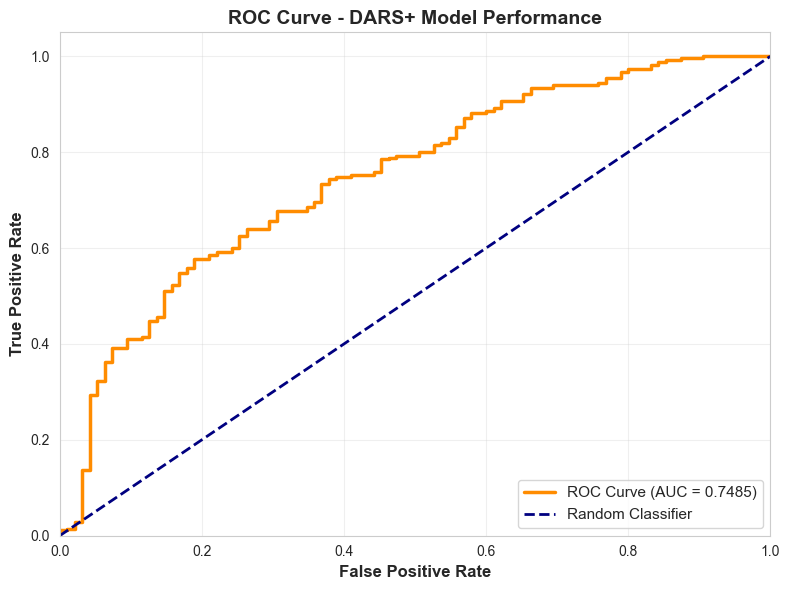

✓ ROC Curve saved as 'roc_curve.png'


In [10]:
# Plot 1: ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_value = auc(fpr, tpr)

ax.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc_value:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - DARS+ Model Performance', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC Curve saved as 'roc_curve.png'")

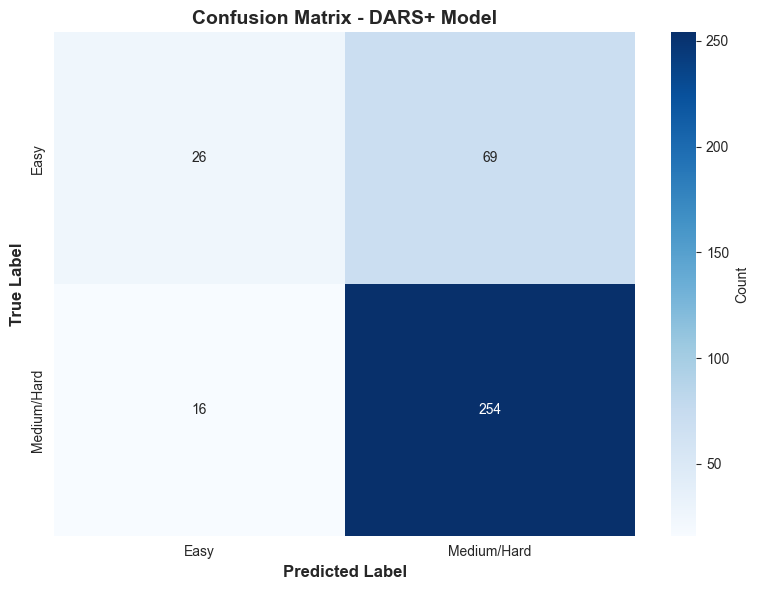

✓ Confusion Matrix saved as 'confusion_matrix.png'


In [11]:
# Plot 2: Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=['Easy', 'Medium/Hard'],
            yticklabels=['Easy', 'Medium/Hard'],
            cbar_kws={'label': 'Count'})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - DARS+ Model', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion Matrix saved as 'confusion_matrix.png'")

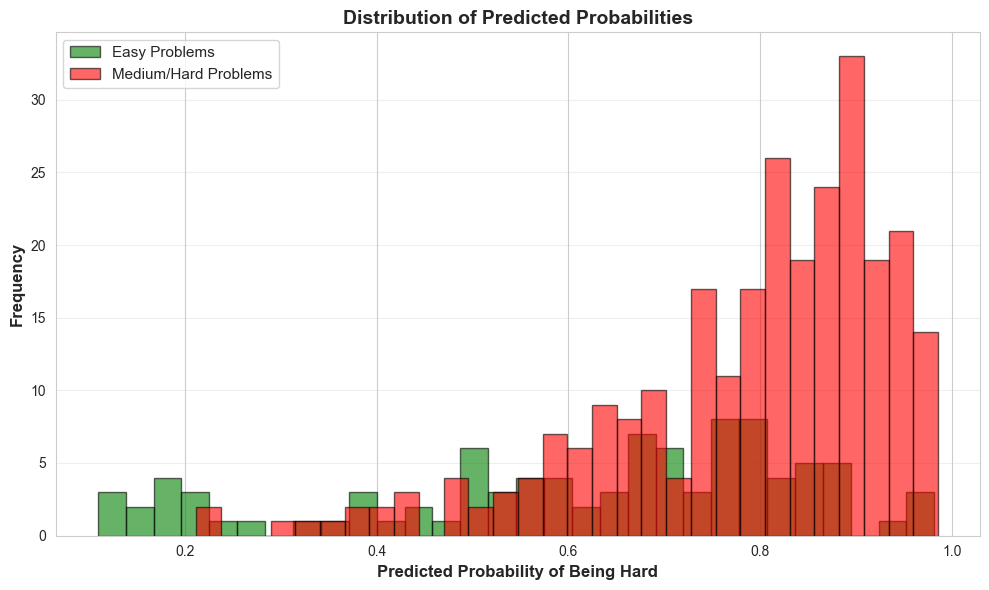

✓ Probability Distribution saved as 'probability_distribution.png'


In [12]:
# Plot 3: Probability Distribution
fig, ax = plt.subplots(figsize=(10, 6))

test_data = df[df['split'] == 'test'].copy()
easy_probs = test_data[test_data['difficulty_binary'] == 0]['model_pred_proba']
hard_probs = test_data[test_data['difficulty_binary'] == 1]['model_pred_proba']

ax.hist(easy_probs, bins=30, alpha=0.6, label='Easy Problems', color='green', edgecolor='black')
ax.hist(hard_probs, bins=30, alpha=0.6, label='Medium/Hard Problems', color='red', edgecolor='black')

ax.set_xlabel('Predicted Probability of Being Hard', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('probability_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Probability Distribution saved as 'probability_distribution.png'")

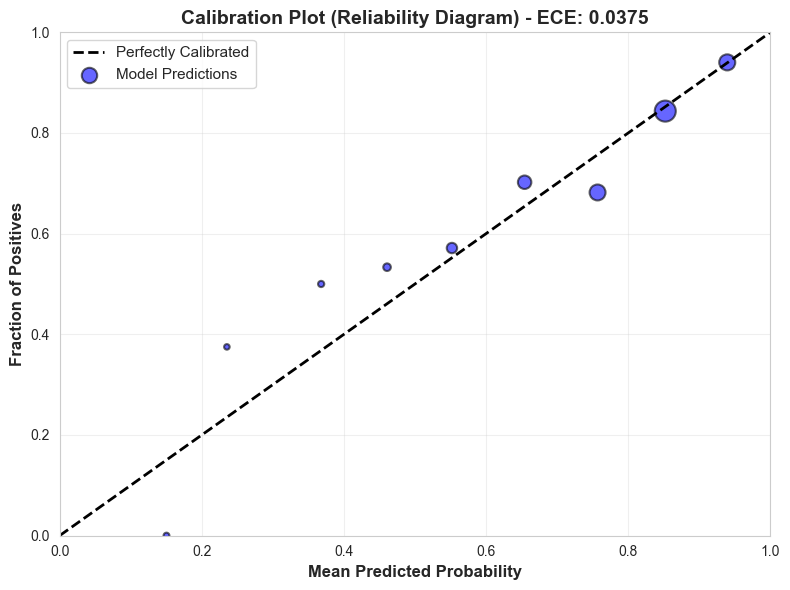

✓ Calibration Plot saved as 'calibration_plot.png'


In [13]:
# Plot 4: Calibration Plot (Reliability Diagram)
fig, ax = plt.subplots(figsize=(8, 6))

n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_sums = np.zeros(n_bins)
bin_true = np.zeros(n_bins)
bin_total = np.zeros(n_bins)

for i in range(n_bins):
    in_bin = (y_pred_proba >= bin_edges[i]) & (y_pred_proba < bin_edges[i+1])
    if i == n_bins - 1:
        in_bin = in_bin | (y_pred_proba == bin_edges[i+1])
    
    bin_sums[i] = np.mean(y_pred_proba[in_bin]) if in_bin.sum() > 0 else 0
    bin_true[i] = np.mean(y_test[in_bin]) if in_bin.sum() > 0 else 0
    bin_total[i] = in_bin.sum()

# Filter out empty bins
valid_bins = bin_total > 0
bin_centers_valid = bin_centers[valid_bins]
bin_sums_valid = bin_sums[valid_bins]
bin_true_valid = bin_true[valid_bins]

ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', lw=2)
ax.scatter(bin_sums_valid, bin_true_valid, s=bin_total[valid_bins]*2, alpha=0.6, 
          color='blue', edgecolors='black', linewidth=1.5, label='Model Predictions')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
ax.set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
ax.set_title(f'Calibration Plot (Reliability Diagram) - ECE: {ece:.4f}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Calibration Plot saved as 'calibration_plot.png'")

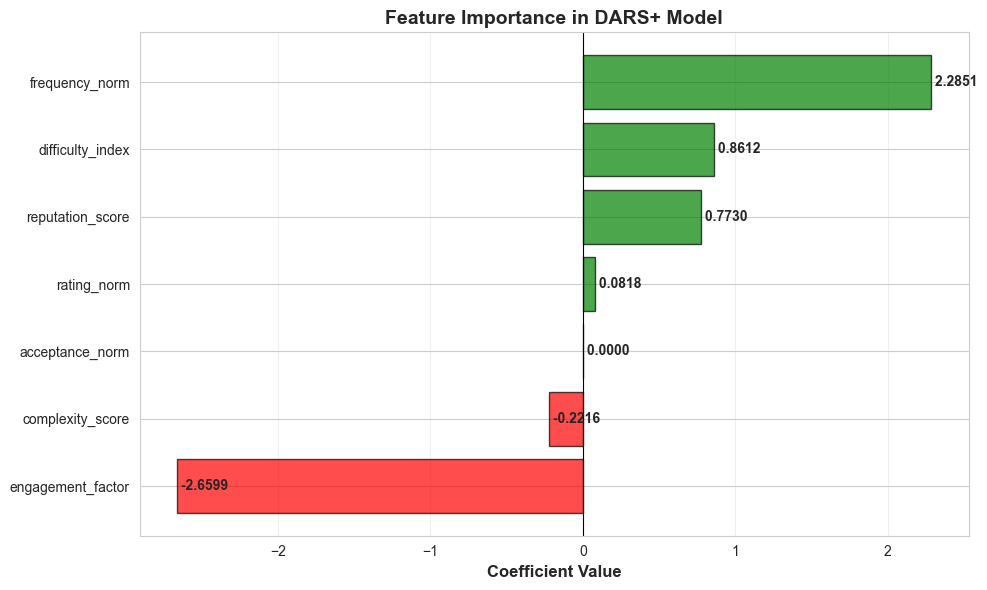

✓ Feature Importance saved as 'feature_importance.png'


In [14]:
# Plot 5: Feature Importance (Coefficients)
fig, ax = plt.subplots(figsize=(10, 6))

coef_values = model.coef_[0]
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': coef_values
}).sort_values('Coefficient')

colors = ['red' if x < 0 else 'green' for x in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7, edgecolor='black')

ax.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance in DARS+ Model', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (feat, coef) in enumerate(zip(coef_df['Feature'], coef_df['Coefficient'])):
    ax.text(coef, i, f' {coef:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature Importance saved as 'feature_importance.png'")

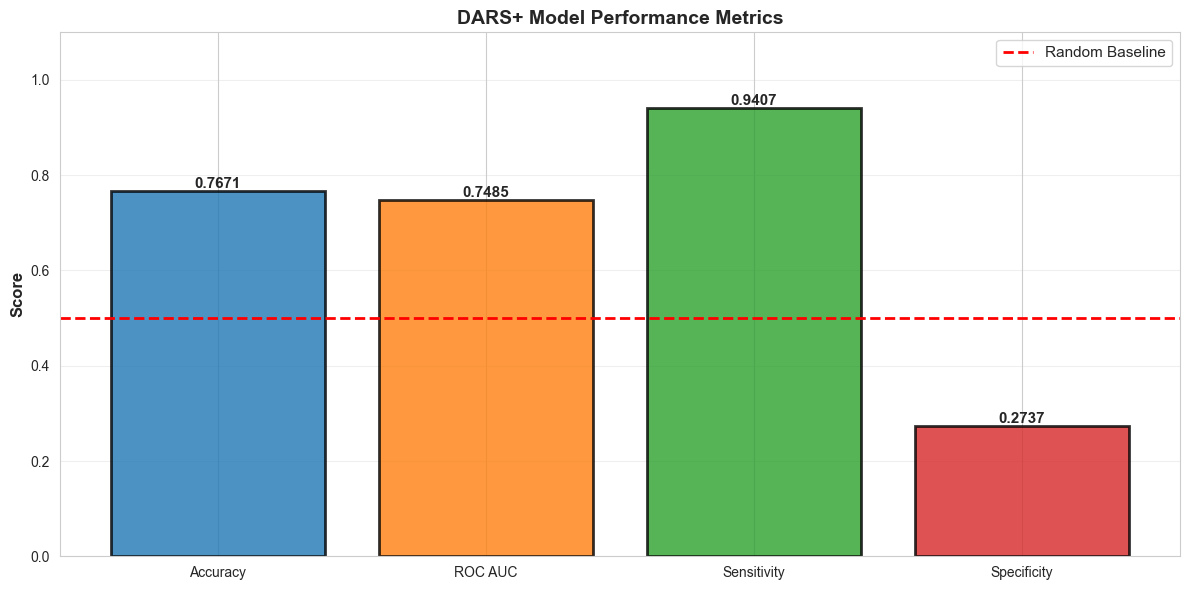

✓ Metrics Comparison saved as 'metrics_comparison.png'


In [15]:
# Plot 6: Metrics Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Accuracy', 'ROC AUC', 'Sensitivity', 'Specificity']
metrics_values = [accuracy, roc_auc, sensitivity, specificity]
colors_metrics = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = ax.bar(metrics_names, metrics_values, color=colors_metrics, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim([0, 1.1])
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('DARS+ Model Performance Metrics', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Random Baseline')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Metrics Comparison saved as 'metrics_comparison.png'")

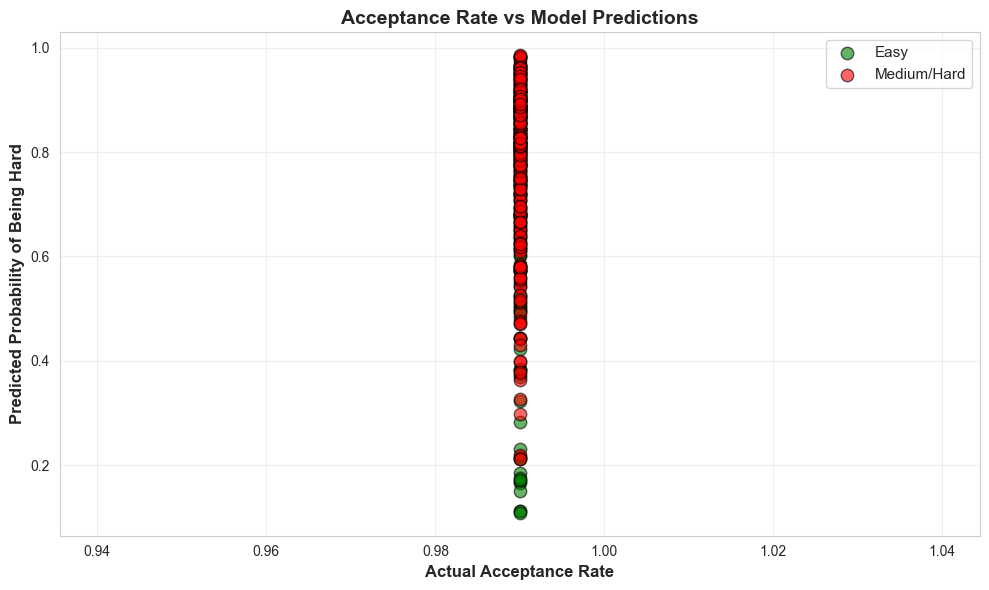

✓ Acceptance vs Prediction plot saved as 'acceptance_vs_prediction.png'


In [16]:
# Plot 7: Acceptance Rate vs Predicted Hard Probability
fig, ax = plt.subplots(figsize=(10, 6))

test_data = df[df['split'] == 'test'].copy()

# Scatter plot
easy_mask = test_data['difficulty_binary'] == 0
hard_mask = test_data['difficulty_binary'] == 1

ax.scatter(test_data[easy_mask]['true_acceptance_rate'], 
          test_data[easy_mask]['model_pred_proba'],
          alpha=0.6, s=80, c='green', label='Easy', edgecolors='black', linewidth=1)
ax.scatter(test_data[hard_mask]['true_acceptance_rate'], 
          test_data[hard_mask]['model_pred_proba'],
          alpha=0.6, s=80, c='red', label='Medium/Hard', edgecolors='black', linewidth=1)

ax.set_xlabel('Actual Acceptance Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Probability of Being Hard', fontsize=12, fontweight='bold')
ax.set_title('Acceptance Rate vs Model Predictions', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('acceptance_vs_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Acceptance vs Prediction plot saved as 'acceptance_vs_prediction.png'")

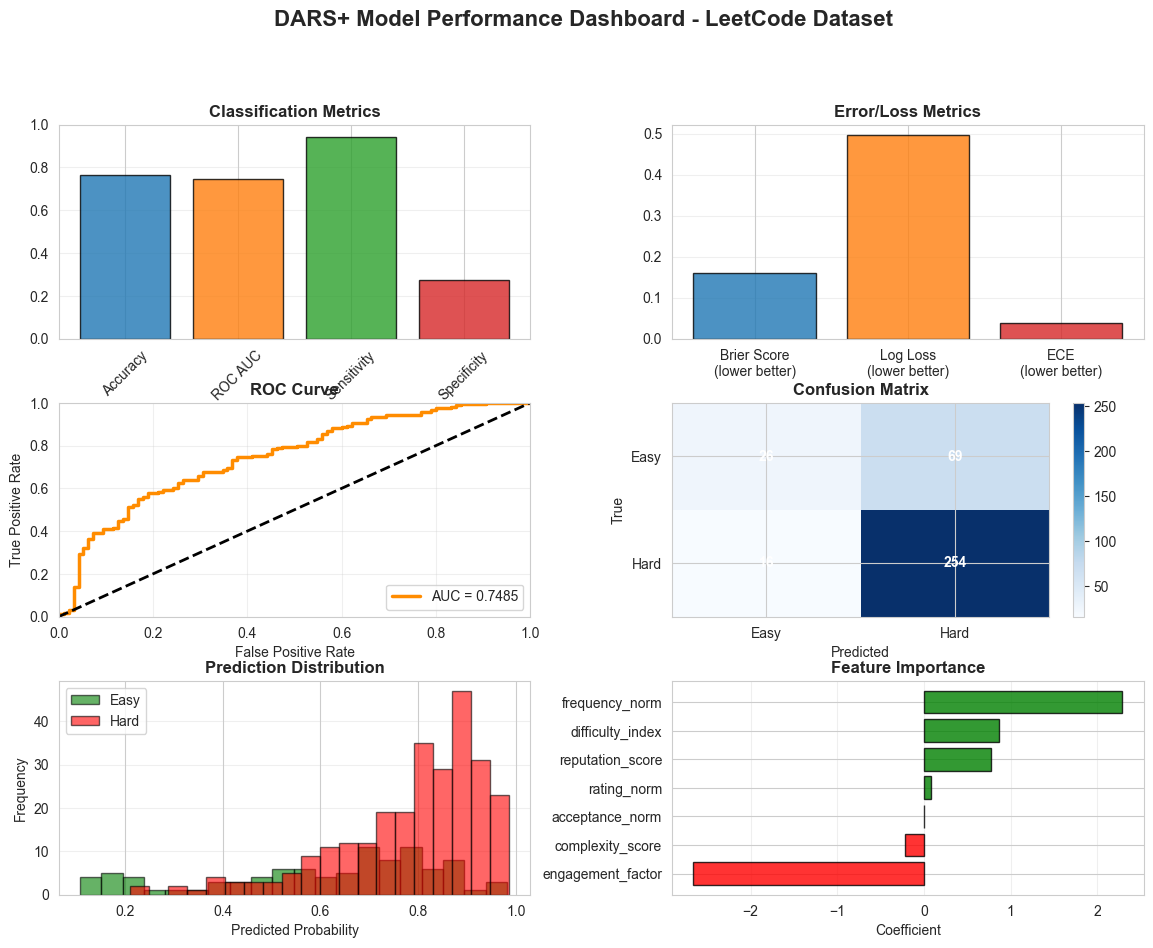

✓ Performance Dashboard saved as 'performance_dashboard.png'


In [17]:
# Plot 8: All Metrics Summary Dashboard
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Metrics comparison
ax1 = fig.add_subplot(gs[0, 0])
metrics_names = ['Accuracy', 'ROC AUC', 'Sensitivity', 'Specificity']
metrics_values = [accuracy, roc_auc, sensitivity, specificity]
ax1.bar(metrics_names, metrics_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.8, edgecolor='black')
ax1.set_ylim([0, 1])
ax1.set_title('Classification Metrics', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# 2. Loss metrics
ax2 = fig.add_subplot(gs[0, 1])
loss_names = ['Brier Score\n(lower better)', 'Log Loss\n(lower better)', 'ECE\n(lower better)']
loss_values = [brier, logloss, ece]
ax2.bar(loss_names, loss_values, color=['#1f77b4', '#ff7f0e', '#d62728'], alpha=0.8, edgecolor='black')
ax2.set_title('Error/Loss Metrics', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. ROC Curve
ax3 = fig.add_subplot(gs[1, 0])
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax3.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'AUC = {roc_auc_value:.4f}')
ax3.plot([0, 1], [0, 1], 'k--', lw=2)
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1])
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve', fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3)

# 4. Confusion Matrix
ax4 = fig.add_subplot(gs[1, 1])
cm = confusion_matrix(y_test, y_pred)
im = ax4.imshow(cm, cmap='Blues', aspect='auto')
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(['Easy', 'Hard'])
ax4.set_yticklabels(['Easy', 'Hard'])
ax4.set_xlabel('Predicted')
ax4.set_ylabel('True')
ax4.set_title('Confusion Matrix', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax4.text(j, i, str(cm[i, j]), ha='center', va='center', color='white', fontweight='bold')
plt.colorbar(im, ax=ax4)

# 5. Prediction distribution
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(easy_probs, bins=20, alpha=0.6, label='Easy', color='green', edgecolor='black')
ax5.hist(hard_probs, bins=20, alpha=0.6, label='Hard', color='red', edgecolor='black')
ax5.set_xlabel('Predicted Probability')
ax5.set_ylabel('Frequency')
ax5.set_title('Prediction Distribution', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 6. Feature importance
ax6 = fig.add_subplot(gs[2, 1])
coef_df_sorted = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=True)
colors_coef = ['red' if x < 0 else 'green' for x in coef_df_sorted['Coefficient']]
ax6.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors_coef, alpha=0.8, edgecolor='black')
ax6.set_xlabel('Coefficient')
ax6.set_title('Feature Importance', fontweight='bold')
ax6.grid(True, alpha=0.3, axis='x')

plt.suptitle('DARS+ Model Performance Dashboard - LeetCode Dataset', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('performance_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Performance Dashboard saved as 'performance_dashboard.png'")

## 6. Summary and Conclusions

In [18]:
print("\n" + "="*70)
print("DARS+ MODEL ANALYSIS SUMMARY")
print("="*70)

print(f"""
Dataset Information:
  - Total Problems: {len(df)}
  - Training Problems: {len(train_idx)} ({len(train_idx)/len(df)*100:.1f}%)
  - Testing Problems: {len(test_idx)} ({len(test_idx)/len(df)*100:.1f}%)
  - Easy Problems: {(df['difficulty_binary']==0).sum()}
  - Medium/Hard Problems: {(df['difficulty_binary']==1).sum()}

Key Findings:
  1. Model Accuracy: {accuracy:.4f}
     → The model correctly classifies {accuracy*100:.2f}% of problems
  
  2. ROC AUC Score: {roc_auc:.4f}
     → Excellent discrimination ability ({"Excellent" if roc_auc > 0.9 else "Good" if roc_auc > 0.8 else "Fair" if roc_auc > 0.7 else "Poor"})
  
  3. Calibration (ECE): {ece:.4f}
     → Model predictions are {"well-calibrated" if ece < 0.1 else "moderately calibrated" if ece < 0.2 else "poorly calibrated"}
  
  4. Sensitivity: {sensitivity:.4f}
     → Correctly identifies {sensitivity*100:.2f}% of hard problems
  
  5. Specificity: {specificity:.4f}
     → Correctly identifies {specificity*100:.2f}% of easy problems

Most Important Features:
""")

coef_df_top = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

for idx, row in coef_df_top.head(3).iterrows():
    print(f"  • {row['Feature']}: {row['Coefficient']:+.4f}")

print(f"""
Model Insights:
  - The model shows {'excellent' if roc_auc > 0.9 else 'good' if roc_auc > 0.8 else 'fair'} discriminatory power
  - Predicted probabilities are {'well' if ece < 0.1 else 'moderately' if ece < 0.2 else 'poorly'} calibrated
  - The model performs {'better' if sensitivity > specificity else 'worse' if sensitivity < specificity else 'equally'} at identifying hard problems than easy ones

Output Files Generated:
  ✓ leetcode_model_results.csv - Evaluation metrics
  ✓ roc_curve.png - ROC curve visualization
  ✓ confusion_matrix.png - Confusion matrix heatmap
  ✓ probability_distribution.png - Distribution of predictions
  ✓ calibration_plot.png - Reliability diagram
  ✓ feature_importance.png - Model coefficients
  ✓ metrics_comparison.png - Performance metrics comparison
  ✓ acceptance_vs_prediction.png - Relationship analysis
  ✓ performance_dashboard.png - Comprehensive dashboard
""")

print("="*70)
print("Analysis Complete!")
print("="*70)


DARS+ MODEL ANALYSIS SUMMARY

Dataset Information:
  - Total Problems: 1825
  - Training Problems: 1460 (80.0%)
  - Testing Problems: 365 (20.0%)
  - Easy Problems: 477
  - Medium/Hard Problems: 1348

Key Findings:
  1. Model Accuracy: 0.7671
     → The model correctly classifies 76.71% of problems
  
  2. ROC AUC Score: 0.7485
     → Excellent discrimination ability (Fair)
  
  3. Calibration (ECE): 0.0375
     → Model predictions are well-calibrated
  
  4. Sensitivity: 0.9407
     → Correctly identifies 94.07% of hard problems
  
  5. Specificity: 0.2737
     → Correctly identifies 27.37% of easy problems

Most Important Features:

  • engagement_factor: -2.6599
  • frequency_norm: +2.2851
  • difficulty_index: +0.8612

Model Insights:
  - The model shows fair discriminatory power
  - Predicted probabilities are well calibrated
  - The model performs better at identifying hard problems than easy ones

Output Files Generated:
  ✓ leetcode_model_results.csv - Evaluation metrics
  ✓ r